# 04. Gom nhóm và phát hiện bất thường bằng DBSCAN

**Project:** `social-anomaly-clustering`  
**Đề tài:** Ứng dụng kỹ thuật gom nhóm trong phát hiện hành vi bất thường của người dùng mạng xã hội  
**Dataset:** Twitter Bot Detection Dataset  
**Notebook:** `04_dbscan_clustering.ipynb`

Notebook này thực hiện bước **gom nhóm bằng DBSCAN** và phát hiện hành vi bất thường dựa trên các điểm nhiễu (`noise`).

## Mục tiêu

1. Đọc dữ liệu đặc trưng đã chuẩn hóa.
2. Tìm tham số `eps` phù hợp bằng **K-Distance Graph**.
3. Chạy thuật toán **DBSCAN**.
4. Gán nhãn cụm cho từng người dùng.
5. Xác định người dùng bất thường dựa trên nhãn `cluster = -1`.
6. Phân tích tỷ lệ bot trong nhóm bất thường.
7. Phân tích đặc điểm các cụm DBSCAN.
8. Trực quan hóa kết quả bằng PCA.
9. Lưu kết quả, biểu đồ và mô hình.


## 1. Import thư viện và thiết lập đường dẫn

Notebook này sử dụng dữ liệu đã tạo ở bước 02:

```text
datasets/processed/user_features_scaled.csv
datasets/processed/user_features_with_label.csv
```

Trong đó:

- `user_features_scaled.csv`: dữ liệu đã chuẩn hóa, dùng làm đầu vào cho DBSCAN.
- `user_features_with_label.csv`: dữ liệu có `user_id`, feature gốc và `bot_label`, dùng để ghép kết quả và phân tích sau clustering.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

SCALED_FEATURES_PATH = Path("../datasets/processed/user_features_scaled.csv")
FEATURES_WITH_LABEL_PATH = Path("../datasets/processed/user_features_with_label.csv")

RESULT_CSV_DIR = Path("../results/csv")
FIGURE_DIR = Path("../results/figures")
MODEL_DIR = Path("../results/models")

RESULT_CSV_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DBSCAN_RESULT_PATH = RESULT_CSV_DIR / "dbscan_clustered_users.csv"
DBSCAN_ANOMALY_PATH = RESULT_CSV_DIR / "dbscan_anomaly_users.csv"
DBSCAN_CLUSTER_SUMMARY_PATH = RESULT_CSV_DIR / "dbscan_cluster_summary.csv"
DBSCAN_ANOMALY_SUMMARY_PATH = RESULT_CSV_DIR / "dbscan_anomaly_summary.csv"
DBSCAN_MODEL_PATH = MODEL_DIR / "dbscan_model.pkl"
PCA_DBSCAN_MODEL_PATH = MODEL_DIR / "pca_dbscan_model.pkl"

print("Scaled features path:", SCALED_FEATURES_PATH)
print("Features with label path:", FEATURES_WITH_LABEL_PATH)
print("Result csv dir:", RESULT_CSV_DIR)
print("Figure dir:", FIGURE_DIR)
print("Model dir:", MODEL_DIR)

Scaled features path: ../datasets/processed/user_features_scaled.csv
Features with label path: ../datasets/processed/user_features_with_label.csv
Result csv dir: ../results/csv
Figure dir: ../results/figures
Model dir: ../results/models


## 2. Đọc dữ liệu đầu vào

Đọc dữ liệu đã chuẩn hóa và dữ liệu có nhãn dùng để phân tích sau clustering.


In [2]:
df_scaled = pd.read_csv(SCALED_FEATURES_PATH)
df_with_label = pd.read_csv(FEATURES_WITH_LABEL_PATH)

print("Shape df_scaled:", df_scaled.shape)
print("Shape df_with_label:", df_with_label.shape)

df_scaled.head()

Shape df_scaled: (50000, 9)
Shape df_with_label: (50000, 11)


,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days
0,1.199224,-0.885993,-0.915548,-1.00016,1.236852,-1.640290,-1.462696,-2.234834,1.359161
1,0.171153,1.455179,1.607800,0.99984,0.872584,1.432833,-0.292661,0.447460,-1.212668
2,-1.508029,-0.300700,-0.217320,0.99984,-0.098798,0.067001,-0.292661,0.447460,-0.907817
3,0.136884,1.455179,-0.954107,0.99984,-0.827335,-1.298831,0.877374,0.447460,0.084332
4,-0.822649,0.284593,1.198243,-1.00016,-2.041562,-1.298831,-0.292661,0.447460,1.436760


In [3]:
df_with_label.head()

,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label
0,132131,85,1,2353,0,83,5,0,0,1114,1
1,289683,55,5,9617,1,77,14,2,1,186,0
2,779715,6,2,4363,1,61,10,2,1,296,0
3,696168,54,5,2242,1,49,6,4,1,654,1
4,704441,26,3,8438,0,29,6,2,1,1142,1


**Nhận xét:**

`df_scaled` là tập đặc trưng đã chuẩn hóa nên phù hợp để đưa vào DBSCAN.  
`df_with_label` giúp ghép lại `user_id`, các feature gốc và `bot_label` sau khi mô hình đã gom nhóm.

Trong quá trình chạy DBSCAN, **không sử dụng `bot_label` làm input**.


## 3. Kiểm tra dữ liệu trước khi chạy DBSCAN

DBSCAN yêu cầu dữ liệu đầu vào là dạng số và không có giá trị thiếu.


In [4]:
df_scaled.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   retweet_count     50000 non-null  float64
 1   mention_count     50000 non-null  float64
 2   follower_count    50000 non-null  float64
 3   verified          50000 non-null  float64
 4   tweet_length      50000 non-null  float64
 5   username_length   50000 non-null  float64
 6   hashtag_count     50000 non-null  float64
 7   has_hashtag       50000 non-null  float64
 8   account_age_days  50000 non-null  float64
dtypes: float64(9)
memory usage: 3.4 MB


In [5]:
missing_scaled = pd.DataFrame({
    "missing_count": df_scaled.isnull().sum(),
    "missing_percent": (df_scaled.isnull().sum() / len(df_scaled) * 100).round(2)
})

missing_scaled

,missing_count,missing_percent
retweet_count,0,0.0
mention_count,0,0.0
follower_count,0,0.0
verified,0,0.0
tweet_length,0,0.0
username_length,0,0.0
hashtag_count,0,0.0
has_hashtag,0,0.0
account_age_days,0,0.0


In [6]:
df_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
retweet_count,50000.0,-4.376943e-17,1.00001,-1.713643,-0.856918,-0.000192,0.856534,1.713259
mention_count,50000.0,8.384404e-18,1.00001,-1.471286,-0.885993,0.284593,0.869886,1.455179
follower_count,50000.0,-9.251266e-17,1.00001,-1.732927,-0.868739,0.001007,0.862329,1.740846
verified,50000.0,6.835421e-17,1.00001,-1.000160,-1.000160,0.999840,0.999840,0.999840
tweet_length,50000.0,2.117417e-16,1.00001,-2.405830,-0.827335,-0.038087,0.811873,3.361750
username_length,50000.0,1.022471e-16,1.00001,-2.323206,-0.957373,-0.274457,0.749917,3.823040
hashtag_count,50000.0,1.875833e-17,1.00001,-1.462696,-0.877678,-0.292661,0.877374,1.462392
has_hashtag,50000.0,-9.833911e-17,1.00001,-2.234834,0.447460,0.447460,0.447460,0.447460
account_age_days,50000.0,3.922196e-17,1.00001,-1.728142,-0.863475,-0.007123,0.871401,1.724982


**Nhận xét:**

Dữ liệu đã chuẩn hóa nên các feature có thang đo tương đối cân bằng.  
Điều này đặc biệt quan trọng với DBSCAN vì thuật toán này dựa trên khoảng cách giữa các điểm dữ liệu để xác định vùng mật độ cao và điểm nhiễu.


## 4. Tổng quan về DBSCAN

**DBSCAN** là thuật toán gom nhóm dựa trên mật độ dữ liệu.

Khác với K-Means:

| Tiêu chí | K-Means | DBSCAN |
|---|---|---|
| Cần chọn trước số cụm | Có, cần chọn `k` | Không cần chọn số cụm |
| Cơ chế chính | Khoảng cách đến tâm cụm | Mật độ điểm dữ liệu |
| Phát hiện outlier | Dựa vào khoảng cách đến tâm cụm | Có sẵn nhãn noise `-1` |
| Tham số quan trọng | `n_clusters` | `eps`, `min_samples` |

Trong DBSCAN:

```text
cluster = -1
```

được hiểu là điểm nhiễu/noise. Trong bài toán này, các điểm `-1` được xem là **người dùng có hành vi bất thường**.


## 5. Tìm tham số `eps` bằng K-Distance Graph

DBSCAN có 2 tham số quan trọng:

| Tham số | Ý nghĩa |
|---|---|
| `eps` | Bán kính vùng lân cận |
| `min_samples` | Số điểm tối thiểu trong vùng lân cận để tạo thành vùng mật độ cao |

Để chọn `eps`, ta dùng **K-Distance Graph**:

1. Chọn `min_samples`.
2. Tính khoảng cách từ mỗi điểm đến hàng xóm thứ `min_samples`.
3. Sắp xếp các khoảng cách tăng dần.
4. Quan sát vị trí đường cong bắt đầu tăng mạnh.
5. Giá trị tại vùng “gấp khúc” có thể dùng làm `eps` thử nghiệm.


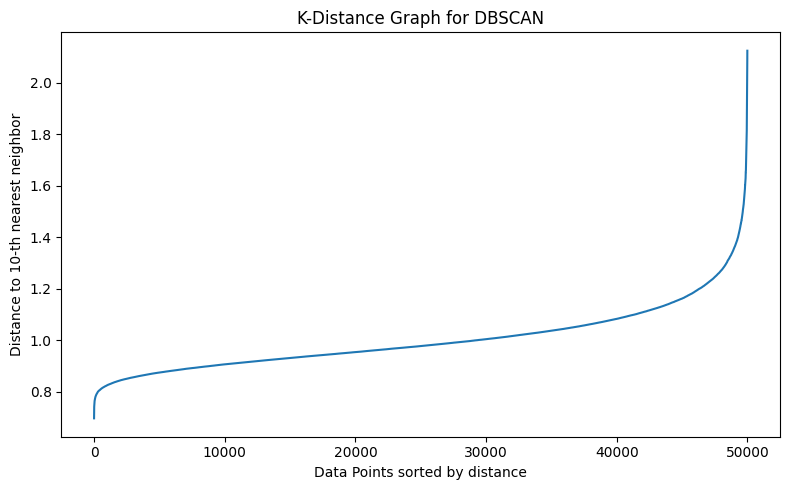

In [7]:
min_samples = 10

neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_scaled)

distances, indices = neighbors_fit.kneighbors(df_scaled)

# Khoảng cách đến hàng xóm thứ min_samples
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title("K-Distance Graph for DBSCAN")
plt.xlabel("Data Points sorted by distance")
plt.ylabel(f"Distance to {min_samples}-th nearest neighbor")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_k_distance_graph.png", dpi=300)
plt.show()

**Cách đọc biểu đồ:**

- Nếu `eps` quá nhỏ: nhiều điểm sẽ bị xem là noise.
- Nếu `eps` quá lớn: nhiều điểm sẽ bị gom vào một cụm lớn, ít hoặc không có noise.
- Nên chọn `eps` gần khu vực đường cong bắt đầu tăng mạnh.

Trong thực nghiệm, có thể thử nhiều giá trị `eps` khác nhau để chọn kết quả phù hợp.


## 6. Thử nhiều giá trị `eps`

Trước khi chốt tham số chính thức, ta thử một số giá trị `eps` để xem số cụm và tỷ lệ noise thay đổi như thế nào.

Điều này giúp tránh trường hợp:

```text
noise quá nhiều  -> eps quá nhỏ
noise quá ít     -> eps quá lớn
chỉ có 1 cụm     -> eps quá lớn hoặc dữ liệu không tách rõ theo mật độ
```


In [8]:
eps_values = [1.2, 1.5, 1.8, 2.0, 2.2, 2.5, 3.0]
min_samples = 10

dbscan_tuning_results = []

for eps in eps_values:
    dbscan_temp = DBSCAN(eps=eps, min_samples=min_samples)
    labels_temp = dbscan_temp.fit_predict(df_scaled)
    
    n_clusters_temp = len(set(labels_temp)) - (1 if -1 in labels_temp else 0)
    n_noise_temp = list(labels_temp).count(-1)
    noise_ratio_temp = n_noise_temp / len(labels_temp) * 100
    
    if n_clusters_temp >= 2:
        try:
            silhouette_temp = silhouette_score(df_scaled, labels_temp)
        except Exception:
            silhouette_temp = np.nan
    else:
        silhouette_temp = np.nan
    
    dbscan_tuning_results.append({
        "eps": eps,
        "min_samples": min_samples,
        "n_clusters": n_clusters_temp,
        "n_noise": n_noise_temp,
        "noise_ratio_percent": round(noise_ratio_temp, 2),
        "silhouette_score": silhouette_temp
    })

tuning_df = pd.DataFrame(dbscan_tuning_results)
tuning_df

,eps,min_samples,n_clusters,n_noise,noise_ratio_percent,silhouette_score
0,1.2,10,4,442,0.88,0.135301
1,1.5,10,4,30,0.06,0.136720
2,1.8,10,4,1,0.00,0.125687
3,2.0,10,4,0,0.00,0.137154
4,2.2,10,2,0,0.00,0.230892
5,2.5,10,2,0,0.00,0.230892
6,3.0,10,1,0,0.00,NaN


**Nhận xét gợi ý:**

Khi chọn tham số DBSCAN, không nên chỉ nhìn Silhouette Score. Cần quan sát thêm:

- Số cụm có hợp lý không?
- Tỷ lệ noise có quá cao hoặc quá thấp không?
- Nhóm noise có ý nghĩa với bài toán phát hiện bất thường không?

Với bài toán anomaly detection, một tỷ lệ noise vừa phải thường dễ diễn giải hơn. Ví dụ khoảng 3% đến 15% có thể là vùng thử nghiệm hợp lý, tùy dữ liệu.


## 7. Chọn tham số DBSCAN chính thức

Sau khi xem K-Distance Graph và bảng thử nghiệm `eps`, chọn tham số chính thức.

Có thể chỉnh lại hai giá trị dưới đây sau khi quan sát kết quả thực tế.


In [24]:
# Có thể chỉnh lại eps sau khi xem K-Distance Graph và bảng tuning_df
selected_eps = 1.1
selected_min_samples = 15

print("Selected eps:", selected_eps)
print("Selected min_samples:", selected_min_samples)

Selected eps: 1.1
Selected min_samples: 15


## 8. Chạy DBSCAN chính thức

Sử dụng `selected_eps` và `selected_min_samples` để chạy DBSCAN trên dữ liệu đã chuẩn hóa.


In [25]:
dbscan = DBSCAN(
    eps=selected_eps,
    min_samples=selected_min_samples
)

dbscan_labels = dbscan.fit_predict(df_scaled)

df_dbscan_result = df_with_label.copy()
df_dbscan_result["cluster"] = dbscan_labels

df_dbscan_result.head()

,user_id,retweet_count,mention_count,follower_count,verified,tweet_length,username_length,hashtag_count,has_hashtag,account_age_days,bot_label,cluster
0,132131,85,1,2353,0,83,5,0,0,1114,1,2
1,289683,55,5,9617,1,77,14,2,1,186,0,0
2,779715,6,2,4363,1,61,10,2,1,296,0,0
3,696168,54,5,2242,1,49,6,4,1,654,1,0
4,704441,26,3,8438,0,29,6,2,1,1142,1,1


In [26]:
df_dbscan_result["cluster"].value_counts().sort_index()

cluster
-1     2816
 0    20009
 1    19914
 2     3651
 3     3610
Name: count, dtype: int64

**Nhận xét:**

Nhãn cụm của DBSCAN có thể gồm:

```text
0, 1, 2, ...  -> các cụm hợp lệ
-1            -> noise/outlier
```

Trong bài toán này, các điểm có `cluster = -1` được xem là các người dùng có hành vi bất thường.


## 9. Thống kê số cụm và số điểm noise

Kiểm tra số cụm hợp lệ, số điểm noise và tỷ lệ noise trên toàn dataset.


In [27]:
n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
noise_ratio = n_noise / len(dbscan_labels) * 100

print("Số cụm DBSCAN tìm được:", n_clusters)
print("Số noise/anomaly:", n_noise)
print(f"Tỷ lệ noise/anomaly: {noise_ratio:.2f}%")

Số cụm DBSCAN tìm được: 4
Số noise/anomaly: 2816
Tỷ lệ noise/anomaly: 5.63%


**Cách diễn giải:**

- Nếu số noise quá cao, ví dụ trên 30%, `eps` có thể đang quá nhỏ.
- Nếu gần như không có noise, `eps` có thể đang quá lớn.
- Nếu chỉ có 1 cụm, DBSCAN chưa tách được cấu trúc dữ liệu rõ ràng với bộ tham số hiện tại.


## 10. Đánh dấu người dùng bất thường

Theo DBSCAN:

```text
cluster = -1 -> noise -> anomaly
```

Tạo cột `is_anomaly` để đánh dấu người dùng bất thường.


In [28]:
df_dbscan_result["is_anomaly"] = (
    df_dbscan_result["cluster"] == -1
).astype(int)

df_dbscan_result["is_anomaly"].value_counts()

is_anomaly
0    47184
1     2816
Name: count, dtype: int64

## 11. Phân tích nhóm bất thường của DBSCAN

Phân tích xem nhóm noise/anomaly có tỷ lệ bot cao hơn nhóm còn lại hay không.


In [29]:
dbscan_anomaly_summary = df_dbscan_result.groupby("is_anomaly").agg(
    user_count=("user_id", "count"),
    bot_count=("bot_label", "sum"),
    bot_ratio=("bot_label", "mean"),
    avg_retweet_count=("retweet_count", "mean"),
    avg_mention_count=("mention_count", "mean"),
    avg_follower_count=("follower_count", "mean"),
    avg_verified=("verified", "mean"),
    avg_tweet_length=("tweet_length", "mean"),
    avg_username_length=("username_length", "mean"),
    avg_hashtag_count=("hashtag_count", "mean"),
    avg_account_age_days=("account_age_days", "mean")
).reset_index()

dbscan_anomaly_summary["bot_ratio"] = (
    dbscan_anomaly_summary["bot_ratio"] * 100
).round(2)

dbscan_anomaly_summary["avg_verified"] = (
    dbscan_anomaly_summary["avg_verified"] * 100
).round(2)

dbscan_anomaly_summary.round(2)

,is_anomaly,user_count,bot_count,bot_ratio,avg_retweet_count,avg_mention_count,avg_follower_count,avg_verified,avg_tweet_length,avg_username_length,avg_hashtag_count,avg_account_age_days
0,0,47184,23602,50.02,49.96,2.51,4992.97,50.06,62.23,9.60,2.54,624.59
1,1,2816,1416,50.28,50.76,2.53,4915.41,49.18,69.21,13.14,1.84,606.49


**Nhận xét:**

Nếu nhóm `is_anomaly = 1` có `bot_ratio` cao hơn nhóm thường, có thể nhận xét DBSCAN phát hiện được một phần tài khoản bot/bất thường.

Nếu `bot_ratio` không chênh lệch nhiều, có thể nhận xét:

```text
Các đặc trưng hiện tại chưa đủ mạnh để tách biệt bot và human rõ ràng.
Tuy nhiên, DBSCAN vẫn giúp phát hiện các tài khoản nằm ngoài vùng mật độ hành vi phổ biến.
```


Nhóm anomaly do DBSCAN phát hiện có tỷ lệ bot cao hơn nhóm normal, nhưng mức chênh lệch không lớn. Điều này cho thấy các đặc trưng hiện tại chưa đủ mạnh để tách biệt rõ bot và human. Tuy nhiên, DBSCAN vẫn phát hiện được nhóm người dùng có hành vi khác biệt về mật độ dữ liệu.

## 12. Phân tích từng cụm DBSCAN

Tạo bảng thống kê theo từng cụm, bao gồm cả cụm `-1` nếu có.


In [30]:
dbscan_cluster_summary = df_dbscan_result.groupby("cluster").agg(
    user_count=("user_id", "count"),
    bot_count=("bot_label", "sum"),
    bot_ratio=("bot_label", "mean"),
    avg_retweet_count=("retweet_count", "mean"),
    avg_mention_count=("mention_count", "mean"),
    avg_follower_count=("follower_count", "mean"),
    avg_verified=("verified", "mean"),
    avg_tweet_length=("tweet_length", "mean"),
    avg_username_length=("username_length", "mean"),
    avg_hashtag_count=("hashtag_count", "mean"),
    avg_account_age_days=("account_age_days", "mean")
).reset_index()

dbscan_cluster_summary["bot_ratio"] = (
    dbscan_cluster_summary["bot_ratio"] * 100
).round(2)

dbscan_cluster_summary["avg_verified"] = (
    dbscan_cluster_summary["avg_verified"] * 100
).round(2)

dbscan_cluster_summary.round(2)

,cluster,user_count,bot_count,bot_ratio,avg_retweet_count,avg_mention_count,avg_follower_count,avg_verified,avg_tweet_length,avg_username_length,avg_hashtag_count,avg_account_age_days
0,-1,2816,1416,50.28,50.76,2.53,4915.41,49.18,69.21,13.14,1.84,606.49
1,0,20009,9946,49.71,50.12,2.52,4986.09,100.00,62.16,9.65,3.01,622.49
2,1,19914,10008,50.26,49.74,2.51,4993.21,0.00,62.22,9.62,3.00,626.10
3,2,3651,1815,49.71,49.31,2.47,4908.81,0.00,62.20,9.47,0.00,619.05
4,3,3610,1833,50.78,50.92,2.54,5114.86,100.00,62.77,9.38,0.00,633.51


**Cách diễn giải bảng cụm:**

- `cluster = -1`: nhóm noise/anomaly.
- Cụm có `bot_ratio` cao hơn có thể chứa nhiều tài khoản bot hơn.
- Cụm có `avg_hashtag_count`, `avg_mention_count`, `avg_retweet_count` cao có thể thể hiện hành vi lan truyền nội dung mạnh.
- Cụm có `avg_follower_count` cao thể hiện nhóm tài khoản có lượng người theo dõi lớn hơn.


Các cụm DBSCAN có tỷ lệ bot dao động quanh 50%, cho thấy nhãn bot/human không hoàn toàn trùng với cấu trúc cụm được hình thành từ các đặc trưng hành vi. Điều này phù hợp với bản chất học không giám sát, vì DBSCAN không sử dụng nhãn trong quá trình gom nhóm.

## 13. Tính Silhouette Score cho DBSCAN

Silhouette Score chỉ có ý nghĩa khi có ít nhất 2 cụm hợp lệ.  
Nếu DBSCAN chỉ tạo 1 cụm hoặc toàn bộ là noise, không thể tính chỉ số này một cách hợp lệ.


In [31]:
labels = df_dbscan_result["cluster"].values
n_valid_clusters = len(set(labels)) - (1 if -1 in set(labels) else 0)

if n_valid_clusters >= 2:
    silhouette_dbscan = silhouette_score(df_scaled, labels)
    print("DBSCAN Silhouette Score:", round(silhouette_dbscan, 6))
else:
    silhouette_dbscan = None
    print("Không tính được Silhouette Score vì số cụm hợp lệ nhỏ hơn 2.")

DBSCAN Silhouette Score: 0.123253


K-Means có Silhouette Score cao hơn DBSCAN trong cấu hình hiện tại, cho thấy các cụm K-Means có độ tách biệt tốt hơn một chút. Tuy nhiên, DBSCAN có lợi thế là tự động phát hiện noise/anomaly thông qua nhãn -1.

## 14. Trực quan hóa số lượng user theo cụm

Biểu đồ này giúp quan sát cụm nào có nhiều user và cụm `-1` có bao nhiêu user bất thường.


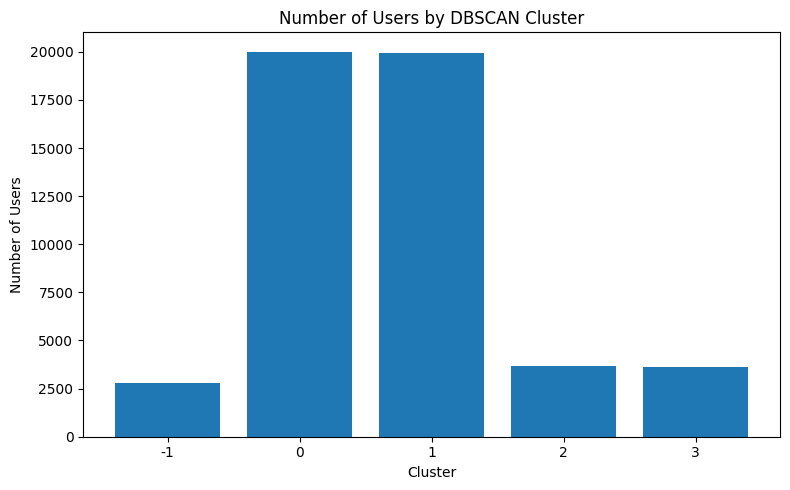

In [32]:
cluster_counts = df_dbscan_result["cluster"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.title("Number of Users by DBSCAN Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_cluster_distribution.png", dpi=300)
plt.show()

## 15. Trực quan hóa tỷ lệ bot theo cụm DBSCAN

Biểu đồ này giúp quan sát cụm nào có tỷ lệ bot cao hơn.


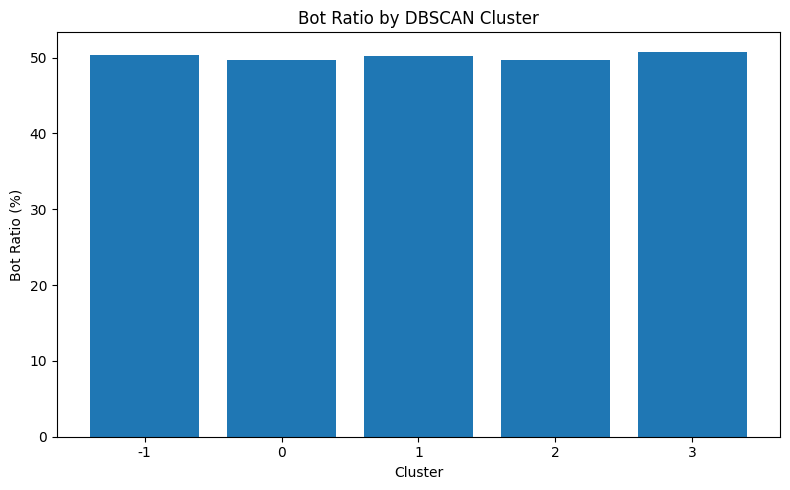

In [33]:
plt.figure(figsize=(8, 5))
plt.bar(
    dbscan_cluster_summary["cluster"].astype(str),
    dbscan_cluster_summary["bot_ratio"]
)
plt.title("Bot Ratio by DBSCAN Cluster")
plt.xlabel("Cluster")
plt.ylabel("Bot Ratio (%)")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "dbscan_bot_ratio_by_cluster.png", dpi=300)
plt.show()

## 16. Giảm chiều dữ liệu bằng PCA để trực quan hóa

Dữ liệu có nhiều chiều nên khó trực quan hóa trực tiếp.  
Ta dùng PCA để giảm dữ liệu về 2 chiều phục vụ biểu đồ.

Lưu ý:

- PCA chỉ dùng để trực quan hóa.
- DBSCAN được chạy trên toàn bộ dữ liệu đã chuẩn hóa, không phải chỉ trên 2 chiều PCA.


In [34]:
pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_scaled)

df_pca_dbscan = pd.DataFrame({
    "pca_1": pca_components[:, 0],
    "pca_2": pca_components[:, 1],
    "cluster": df_dbscan_result["cluster"],
    "is_anomaly": df_dbscan_result["is_anomaly"],
    "bot_label": df_dbscan_result["bot_label"]
})

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

df_pca_dbscan.head()

Explained variance ratio: [0.18386128 0.11307209]
Total explained variance: 0.2969333644811424


,pca_1,pca_2,cluster,is_anomaly,bot_label
0,-2.668869,-0.884062,2,0,1
1,0.136385,0.333582,0,0,0
2,0.135368,-0.292727,0,0,0
3,0.926824,0.783074,0,0,1
4,0.123422,2.764007,1,0,1


## 17. PCA visualization theo cụm DBSCAN

Mỗi điểm là một người dùng. Màu/nhãn biểu diễn cụm DBSCAN.  
Nhóm `Noise (-1)` là các điểm được xem là bất thường.


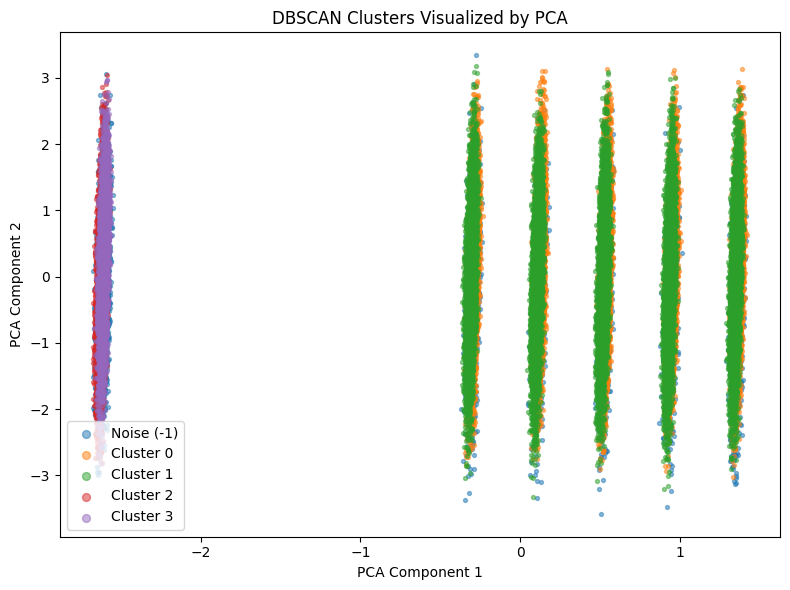

In [35]:
plt.figure(figsize=(8, 6))

for cluster in sorted(df_pca_dbscan["cluster"].unique()):
    subset = df_pca_dbscan[df_pca_dbscan["cluster"] == cluster]
    label = "Noise (-1)" if cluster == -1 else f"Cluster {cluster}"
    plt.scatter(
        subset["pca_1"],
        subset["pca_2"],
        s=8,
        alpha=0.5,
        label=label
    )

plt.title("DBSCAN Clusters Visualized by PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(markerscale=2)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_dbscan.png", dpi=300)
plt.show()

Các điểm anomaly xuất hiện rải rác trên không gian PCA. Điều này cho thấy hành vi bất thường không chỉ tập trung ở một vùng duy nhất mà có thể xuất hiện ở nhiều cụm hành vi khác nhau. Do PCA chỉ giữ lại một phần phương sai của dữ liệu, biểu đồ này chủ yếu dùng để trực quan hóa chứ không thay thế cho kết quả định lượng.

## 18. PCA visualization cho nhóm bất thường

Biểu đồ này tách riêng nhóm normal và anomaly để quan sát các điểm noise của DBSCAN.


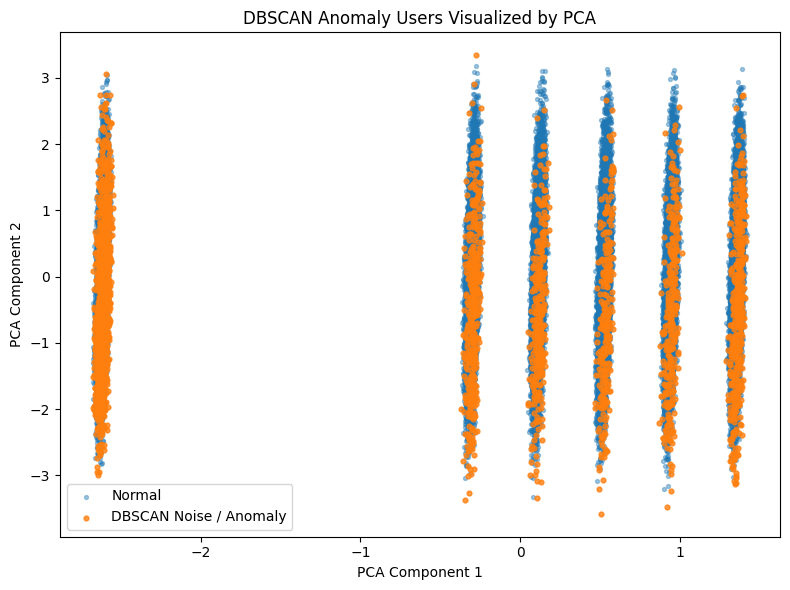

In [36]:
plt.figure(figsize=(8, 6))

normal_points = df_pca_dbscan[df_pca_dbscan["is_anomaly"] == 0]
anomaly_points = df_pca_dbscan[df_pca_dbscan["is_anomaly"] == 1]

plt.scatter(
    normal_points["pca_1"],
    normal_points["pca_2"],
    s=8,
    alpha=0.4,
    label="Normal"
)

plt.scatter(
    anomaly_points["pca_1"],
    anomaly_points["pca_2"],
    s=12,
    alpha=0.8,
    label="DBSCAN Noise / Anomaly"
)

plt.title("DBSCAN Anomaly Users Visualized by PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "pca_dbscan_anomaly.png", dpi=300)
plt.show()

**Nhận xét:**

Nếu nhóm anomaly nằm nhiều ở rìa phân bố PCA, điều đó phù hợp với ý tưởng của DBSCAN: các điểm nằm xa vùng mật độ cao sẽ bị xem là noise.

Tuy nhiên, PCA chỉ giữ lại một phần thông tin của dữ liệu gốc nên biểu đồ chỉ dùng để trực quan hóa, không phải tiêu chí đánh giá duy nhất.


## 19. Lưu kết quả DBSCAN

Lưu các file kết quả:

```text
results/csv/dbscan_clustered_users.csv
results/csv/dbscan_anomaly_users.csv
results/csv/dbscan_cluster_summary.csv
results/csv/dbscan_anomaly_summary.csv
results/models/dbscan_model.pkl
results/models/pca_dbscan_model.pkl
```


In [37]:
df_dbscan_result.to_csv(DBSCAN_RESULT_PATH, index=False)

df_dbscan_result[df_dbscan_result["is_anomaly"] == 1].to_csv(
    DBSCAN_ANOMALY_PATH,
    index=False
)

dbscan_cluster_summary.to_csv(DBSCAN_CLUSTER_SUMMARY_PATH, index=False)
dbscan_anomaly_summary.to_csv(DBSCAN_ANOMALY_SUMMARY_PATH, index=False)

joblib.dump(dbscan, DBSCAN_MODEL_PATH)
joblib.dump(pca, PCA_DBSCAN_MODEL_PATH)

print("Saved DBSCAN result to:", DBSCAN_RESULT_PATH)
print("Saved DBSCAN anomaly users to:", DBSCAN_ANOMALY_PATH)
print("Saved DBSCAN cluster summary to:", DBSCAN_CLUSTER_SUMMARY_PATH)
print("Saved DBSCAN anomaly summary to:", DBSCAN_ANOMALY_SUMMARY_PATH)
print("Saved DBSCAN model to:", DBSCAN_MODEL_PATH)
print("Saved PCA model to:", PCA_DBSCAN_MODEL_PATH)

Saved DBSCAN result to: ../results/csv/dbscan_clustered_users.csv
Saved DBSCAN anomaly users to: ../results/csv/dbscan_anomaly_users.csv
Saved DBSCAN cluster summary to: ../results/csv/dbscan_cluster_summary.csv
Saved DBSCAN anomaly summary to: ../results/csv/dbscan_anomaly_summary.csv
Saved DBSCAN model to: ../results/models/dbscan_model.pkl
Saved PCA model to: ../results/models/pca_dbscan_model.pkl


## 20. Kết luận DBSCAN Clustering

Sau khi thực hiện DBSCAN, có thể rút ra một số ý chính:

1. DBSCAN được sử dụng để gom nhóm người dùng dựa trên mật độ dữ liệu.
2. Khác với K-Means, DBSCAN không cần chọn trước số cụm.
3. Hai tham số quan trọng là `eps` và `min_samples`.
4. K-Distance Graph được dùng để hỗ trợ chọn `eps`.
5. Các điểm có `cluster = -1` được xem là noise/outlier.
6. Trong bài toán này, noise được diễn giải là nhóm người dùng có hành vi bất thường.
7. Bảng `dbscan_anomaly_summary` giúp đánh giá nhóm anomaly có tỷ lệ bot cao hơn nhóm thường hay không.
8. Bảng `dbscan_cluster_summary` giúp phân tích đặc điểm từng cụm.
9. PCA được dùng để trực quan hóa cụm và nhóm bất thường trên mặt phẳng 2 chiều.

Notebook tiếp theo:

```text
05_evaluation_visualization.ipynb
```

Trong bước tiếp theo, ta sẽ tổng hợp kết quả từ K-Means và DBSCAN, so sánh hai phương pháp và chuẩn bị các biểu đồ/bảng kết quả cho báo cáo hoặc demo sản phẩm.
